In [1]:
import torch
import torch.nn as nn
from torchvision import models
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import numpy as np

## 1. Base line setup 
(a) Use a pre-trained ResNet-152 from PyTorch. 
(b) Replace the final classification layer to match a smaller dataset such as CIFAR-10.
(c) Train only the classification head while freezing the rest of the backbone.
(d) Record training and validation performance for a few epochs

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
model = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V1)

Downloading: "https://download.pytorch.org/models/resnet152-394f9c45.pth" to /root/.cache/torch/hub/checkpoints/resnet152-394f9c45.pth


100%|██████████| 230M/230M [00:01<00:00, 219MB/s]


In [4]:
#freeze all existing layers
for param in model.parameters():
    param.requires_grad = False

In [5]:
#replacing last layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)

In [6]:
if torch.cuda.device_count() > 1:
    print(f"Let's use {torch.cuda.device_count()} GPUs!")
    # This automatically splits batches across your two T4s
    model = nn.DataParallel(model)

Let's use 2 GPUs!


In [7]:
model = model.to(device)

In [8]:
transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [9]:
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
val_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

100%|██████████| 170M/170M [30:01<00:00, 94.7kB/s]


In [10]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=2)

In [11]:
print(f"CIFAR-10 dataset loaded. Training samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")

CIFAR-10 dataset loaded. Training samples: 50000, Validation samples: 10000


In [12]:
import torch.optim as optim
import torch.nn as nn

In [13]:
#using cross entropy loss nad adam optimizer 
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.module.fc.parameters(), lr=0.001)

epochs = 5

In [14]:
# Initialize tracking lists
base_train_losses = []
base_train_accs = []
base_val_losses = []
base_val_accs = []

print(f"starting training for classification head")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100 * correct_train / total_train
    
    # Validation
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    val_loss = val_loss / len(val_loader.dataset)
    val_acc = 100 * correct_val / total_val
    
    # Append natively to the lists
    base_train_losses.append(train_loss)
    base_train_accs.append(train_acc)
    base_val_losses.append(val_loss)
    base_val_accs.append(val_acc)
    
    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

starting training for classification head
Epoch [1/5] | Train Loss: 0.7286, Train Acc: 77.03% | Val Loss: 0.5326, Val Acc: 82.16%
Epoch [2/5] | Train Loss: 0.5193, Train Acc: 82.36% | Val Loss: 0.4835, Val Acc: 83.62%
Epoch [3/5] | Train Loss: 0.4883, Train Acc: 83.11% | Val Loss: 0.4744, Val Acc: 83.44%
Epoch [4/5] | Train Loss: 0.4782, Train Acc: 83.47% | Val Loss: 0.4819, Val Acc: 83.48%
Epoch [5/5] | Train Loss: 0.4587, Train Acc: 84.09% | Val Loss: 0.4506, Val Acc: 84.67%


## Residual Connections in Practice
(a) Disable skip connections in a few selected residual blocks and re-train the modified network head. 4
(b) Compare training dynamics and validation accuracy with the baseline.

In [15]:
import torchvision.models.resnet as resnet
import torch
import torch.nn as nn
from torchvision import models

class NoSkipBottleneck(resnet.Bottleneck):
    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
        
        out = self.conv3(out)
        out = self.bn3(out)
        
        # skip connection gone
        out = self.relu(out)
        return out

model = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V1)

for param in model.parameters():
    param.requires_grad = False
model.fc = nn.Linear(model.fc.in_features, 10)

model.layer4[0].__class__ = NoSkipBottleneck
model.layer4[1].__class__ = NoSkipBottleneck

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)

model = model.to(device)
optimizer = torch.optim.Adam(model.module.fc.parameters(), lr=0.001)

print("Fresh model built, blocks updated to NoSkipBottleneck, safely re-wrapped and optimizer reset.")

Fresh model built, blocks updated to NoSkipBottleneck, safely re-wrapped and optimizer reset.


In [16]:
no_skip_train_losses = []
no_skip_train_accs = []
no_skip_val_losses = []
no_skip_val_accs = []

print(f"starting training for classification head without skip connection")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100 * correct_train / total_train
    
    # Validation
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    val_loss = val_loss / len(val_loader.dataset)
    val_acc = 100 * correct_val / total_val
    
    no_skip_train_losses.append(train_loss)
    no_skip_train_accs.append(train_acc)
    no_skip_val_losses.append(val_loss)
    no_skip_val_accs.append(val_acc)
    
    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

starting training for classification head without skip connection
Epoch [1/5] | Train Loss: 1.0199, Train Acc: 68.36% | Val Loss: 0.7938, Val Acc: 73.45%
Epoch [2/5] | Train Loss: 0.7763, Train Acc: 73.74% | Val Loss: 0.7416, Val Acc: 74.66%
Epoch [3/5] | Train Loss: 0.7387, Train Acc: 74.82% | Val Loss: 0.7112, Val Acc: 75.73%
Epoch [4/5] | Train Loss: 0.7205, Train Acc: 75.40% | Val Loss: 0.7086, Val Acc: 76.02%
Epoch [5/5] | Train Loss: 0.7075, Train Acc: 75.67% | Val Loss: 0.6881, Val Acc: 76.67%


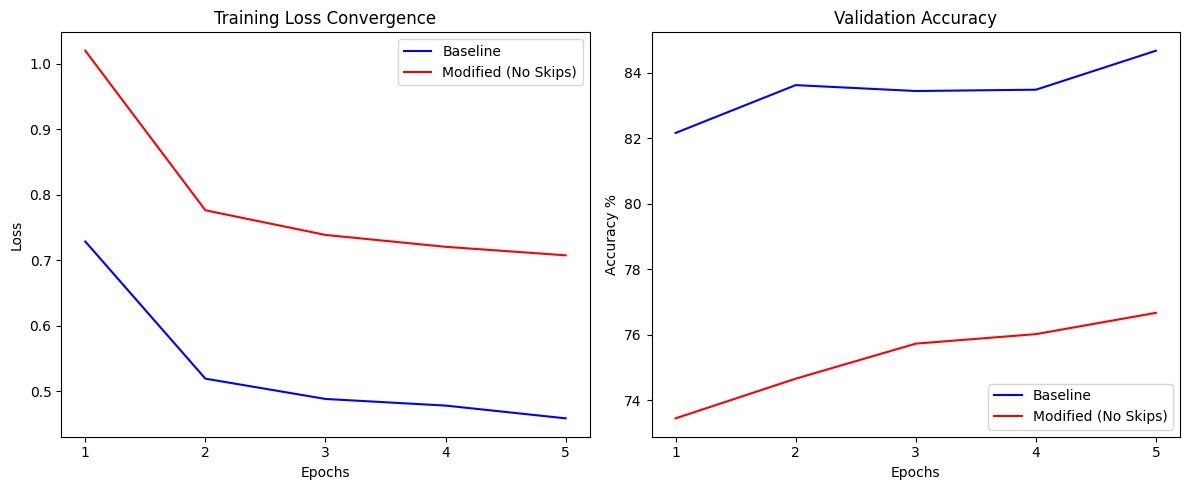

In [17]:
import matplotlib.pyplot as plt

epochs_range = list(range(1, epochs + 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Training Loss
ax1.plot(epochs_range, base_train_losses, label='Baseline', color='blue')
ax1.plot(epochs_range, no_skip_train_losses, label='Modified (No Skips)', color='red')
ax1.set_title('Training Loss Convergence')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_xticks(epochs_range)
ax1.legend()

# Plot 2: Validation Accuracy
ax2.plot(epochs_range, base_val_accs, label='Baseline', color='blue')
ax2.plot(epochs_range, no_skip_val_accs, label='Modified (No Skips)', color='red')
ax2.set_title('Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy %')
ax2.set_xticks(epochs_range)
ax2.legend()

plt.tight_layout()
plt.show()

## 3. Feature Hierarchies and Representations
(a) Collect features from early, middle, and late layers of the network.
(b) Visualize these features using dimensionality reduction (t-SNE or UMAP).

Hooks registered successfully. Extracting features...
Computing t-SNE for the early layer...
Computing t-SNE for the middle layer...
Computing t-SNE for the late layer...


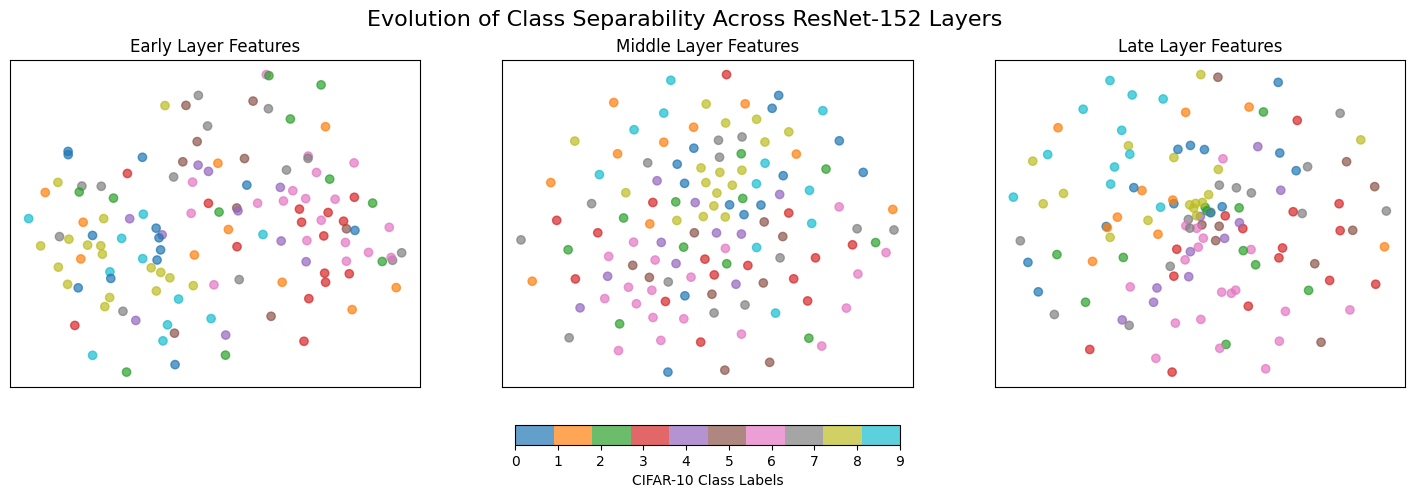

In [18]:
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

features = {}

# Hook function
def get_features(name):
    def hook(model, input, output):
        features[name] = output.detach().cpu()
    return hook

base_model = model.module if isinstance(model, torch.nn.DataParallel) else model

#hooks
handle_early = base_model.conv1.register_forward_hook(get_features('early'))
handle_middle = base_model.layer2.register_forward_hook(get_features('middle'))
handle_late = base_model.layer4.register_forward_hook(get_features('late'))

print("Hooks registered successfully. Extracting features...")

base_model.eval()
data_iter = iter(val_loader)
images, labels = next(data_iter)


with torch.no_grad():
    _ = base_model(images.to(device))

labels = labels.numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
layer_names = ['early', 'middle', 'late']

for i, name in enumerate(layer_names):
    print(f"Computing t-SNE for the {name} layer...")
    layer_feat = features[name]
    
    #flatten features (Batch, Channels, Height, Width) to (Batch, Features)
    flattened_feat = layer_feat.view(layer_feat.size(0), -1).numpy()
    
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    projected_feat = tsne.fit_transform(flattened_feat)
    
    scatter = axes[i].scatter(
        projected_feat[:, 0], 
        projected_feat[:, 1], 
        c=labels, 
        cmap='tab10', 
        alpha=0.7
    )
    
    axes[i].set_title(f"{name.capitalize()} Layer Features")
    axes[i].set_xticks([])
    axes[i].set_yticks([])

cbar = plt.colorbar(scatter, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1)
cbar.set_label('CIFAR-10 Class Labels')

plt.suptitle("Evolution of Class Separability Across ResNet-152 Layers", fontsize=16)
plt.show()

# Cleanup
handle_early.remove()
handle_middle.remove()
handle_late.remove()

 early (conv1): Sep = 0.6229
middle (layer2): Sep = 0.4791
  late (layer4): Sep = 0.4833


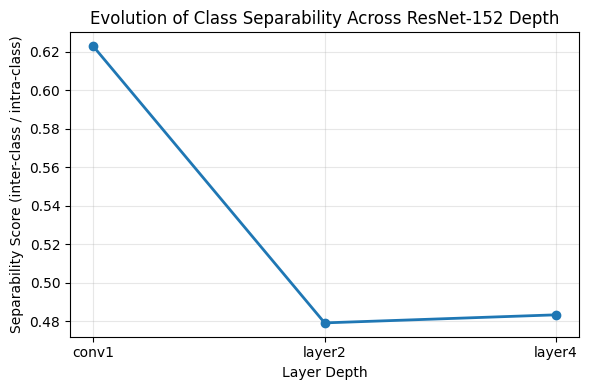

In [19]:
def separability_score(flat_feats, labels):
    classes = np.unique(labels)
    centroids = {c: flat_feats[labels == c].mean(axis=0) for c in classes}

    intra_dists = []
    for c in classes:
        pts = flat_feats[labels == c]
        d = np.linalg.norm(pts - centroids[c], axis=1)
        intra_dists.append(d.mean())
    intra = np.mean(intra_dists)

    cent_matrix = np.stack([centroids[c] for c in classes])
    n = len(classes)
    inter_dists = []
    for i in range(n):
        for j in range(i + 1, n):
            inter_dists.append(np.linalg.norm(cent_matrix[i] - cent_matrix[j]))
    inter = np.mean(inter_dists)

    return inter / intra

sep_scores = {}
for name in layer_names:
    layer_feat = features[name]
    flat = layer_feat.view(layer_feat.size(0), -1).numpy()
    sep_scores[name] = separability_score(flat, labels)
    print(f"{name:>6} ({['conv1','layer2','layer4'][layer_names.index(name)]}): "
          f"Sep = {sep_scores[name]:.4f}")

label_map = {'early': 'conv1', 'middle': 'layer2', 'late': 'layer4'}
depths = [label_map[n] for n in layer_names]
values = [sep_scores[n] for n in layer_names]

plt.figure(figsize=(6, 4))
plt.plot(depths, values, marker='o', linewidth=2)
plt.ylabel("Separability Score (inter-class / intra-class)")
plt.xlabel("Layer Depth")
plt.title("Evolution of Class Separability Across ResNet-152 Depth")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()